In [62]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
import ztpcraft as ztpc
from ztpcraft.toolbox.memory_benchmark import (
    array_bytes,
    benchmark_memory,
    theoretical_bytes,
)
import dynamiqs as dq
import jax.numpy as jnp

In [64]:
# Random open system in an n-dimensional Hilbert space.
#   dρ/dt = -i[H(t), ρ] + Σ_k D[L_k]ρ
#   H(t) = H0 + ε cos(ωd t) H_drive
#   H0, H_drive, and jump operators are random n×n matrices.

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

n = 120
n_jump = 2
factor = 100

eps = 30000  # drive amplitude
omega_d = 5.0  # drive frequency
gamma = 0.05  # dissipation strength scale
T = 300.0
tsave = jnp.linspace(0, T, 2)
seed = 42

key = jax.random.PRNGKey(seed)
key_H0, key_drive, key_jumps, key_rho0, key_obs = jax.random.split(key, 5)

H0 = factor*dq.random.operator(key_H0, n, hermitian=True)
H_drive = factor*dq.random.operator(key_drive, n, hermitian=False)
H = H0 + dq.modulated(lambda t: eps * jnp.cos(omega_d * t), H_drive)

jump_keys = jax.random.split(key_jumps, n_jump)
jump_ops = [
    factor*jnp.sqrt(gamma) * dq.random.operator(k, n, hermitian=False) for k in jump_keys
]

rho0 = dq.random.dm(key_rho0, n)
obs = dq.random.operator(key_obs, n, hermitian=True)

method = dq.method.Tsit5(rtol=1e-09, atol=1e-09, max_steps=10000000)


In [65]:
# method 1 for obtaining the propagator: direct mepropagator

def _run_mepropagator():
    result = dq.mepropagator(
        H,
        jump_ops,
        tsave=jnp.array([T]),
        method=method,
    )
    return result, result.propagators[-1]


(propagator_result, U_direct), mem_stats_1 = benchmark_memory(
    "method 1: mepropagator",
    _run_mepropagator,
)

print(f"U_direct shape      : {U_direct.shape}")
print(f"U_direct array size : {array_bytes(U_direct) / 1e6:.1f} MB")
print(
    f"theoretical minimum : {theoretical_bytes((n * n, n * n)):.1f} MB "
    "(complex64 output only)"
)

|██████████| 100.0% ◆ elapsed 1.10s ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 713.35ms ◆ remaining 0.00ms


=== method 1: mepropagator ===
host RSS before     :    525.1 MB
host RSS after      :   2999.1 MB
peak host RSS       :   4077.6 MB
peak above baseline :   3552.5 MB
U_direct shape      : (14400, 14400)
U_direct array size : 1658.9 MB
theoretical minimum : 1658.9 MB (complex64 output only)


In [32]:
# method 2 for obtaining the propagator: mesolve with batched |i><j| initial states
# order (j, i) so batch index matches dynamiqs vectorize convention: index = i + n*j

def _make_rho0_batch():
    idx = jnp.arange(n * n)
    i_idx = idx % n
    j_idx = idx // n
    rho = jnp.zeros((n * n, n, n), dtype=jnp.complex64)
    rho = rho.at[jnp.arange(n * n), i_idx, j_idx].set(1.0)
    return dq.asqarray(rho)


def _run_batched_mesolve():
    rho0_batch = _make_rho0_batch()
    result = dq.mesolve(
        H,
        jump_ops,
        rho0_batch,
        tsave=jnp.array([T]),
        method=method,
        cartesian_batching=False,
        assume_hermitian=False,
    )
    final = result.states[:, -1]
    del result, rho0_batch
    U = dq.vectorize(final).squeeze(-1).T
    del final
    return U


U_from_mesolve, mem_stats_2 = benchmark_memory(
    "method 2: batched mesolve",
    _run_batched_mesolve,
)

print(f"rho0_batch shape    : {rho0_batch.shape}")
print(f"rho0_batch size     : {array_bytes(rho0_batch) / 1e6:.1f} MB")
print(f"final states shape  : {mesolve_result.states[:, -1].shape}")
print(f"final states size   : {array_bytes(mesolve_result.states[:, -1]) / 1e6:.1f} MB")
print(f"U_from_mesolve shape: {U_from_mesolve.shape}")
print(f"U_from_mesolve size : {array_bytes(U_from_mesolve) / 1e6:.1f} MB")
print(
    f"theoretical minimum : {theoretical_bytes((n * n, n * n)):.1f} MB "
    "(complex64 propagator only)"
)

|██████████| 100.0% ◆ elapsed 364.22ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 212.82ms ◆ remaining 0.00ms


=== method 2: batched mesolve ===
host RSS before     :   1048.8 MB
host RSS after      :   1049.2 MB
peak host RSS       :   2187.9 MB
peak above baseline :   1139.2 MB
rho0_batch shape    : (3600, 60, 60)
rho0_batch size     : 103.7 MB
final states shape  : (3600, 60, 60)
final states size   : 103.7 MB
U_from_mesolve shape: (3600, 3600)
U_from_mesolve size : 103.7 MB
theoretical minimum : 103.7 MB (complex64 propagator only)


In [19]:
print("max |U_direct - U_from_mesolve|:", jnp.max(jnp.abs(dq.to_jax(U_direct - U_from_mesolve))))

max |U_direct - U_from_mesolve|: 0.0


|██████████| 100.0% ◆ elapsed 0.36ms ◆ remaining 0.00ms


max |rhoT_ref - rhoT_direct|: 0.0
max |rhoT_ref - rhoT_mesolve|: 0.0


|██████████| 100.0% ◆ elapsed 8.84ms ◆ remaining 0.00ms


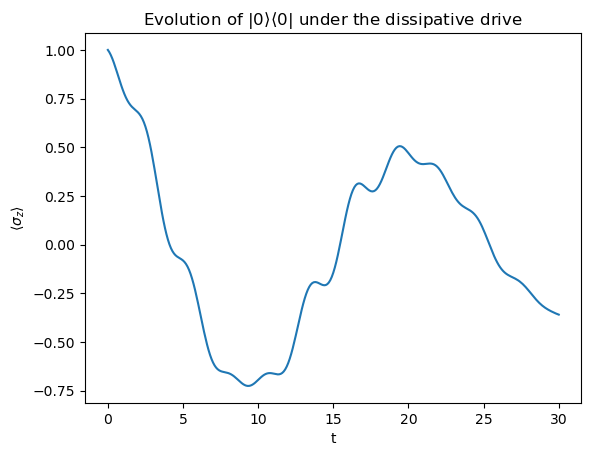

In [13]:
# sanity check: apply both propagators to rho0
rhoT_ref = dq.mesolve(H, jump_ops, rho0, jnp.array([T]), method=method).states[-1]
rhoT_direct = dq.unvectorize(U_direct @ dq.vectorize(rho0))
rhoT_mesolve = dq.unvectorize(U_from_mesolve @ dq.vectorize(rho0))
print("max |rhoT_ref - rhoT_direct|:", jnp.max(jnp.abs(dq.to_jax(rhoT_ref - rhoT_direct))))
print("max |rhoT_ref - rhoT_mesolve|:", jnp.max(jnp.abs(dq.to_jax(rhoT_ref - rhoT_mesolve))))

exp_obs = dq.expect(obs, dq.mesolve(H, jump_ops, rho0, tsave, method=method).states).real
plt.plot(tsave, exp_obs)
plt.xlabel("t")
plt.ylabel(r"$\langle O \rangle$")
plt.title("Evolution of a random observable")
plt.show()